## Classification: Airplane, Automobile, Bird, Cat, Dog

### Installs for fastai

In [3]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_DGRAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai

## Step 1: Download images of birds and non-birds

In [4]:
!pip install -Uqq duckduckgo_search

In [5]:
from duckduckgo_search import DDGS
from fastcore.all import *
from fastai.vision.all import *
from fastdownload import download_url
from time import sleep
import os
from glob import glob
ddgs = DDGS()
def search_images(term, max_images=600): return L(ddgs.images(term, max_results=max_images)).itemgot('image')

Grabbing 200 examples of each search type and saving each group of photos to a different folder:

In [6]:
searches = 'airplane','automobile','bird','cat','dog'
path = Path('elec4630_classification')

# # Download images
# for o in searches:
#     dest = (path/o)
#     dest.mkdir(exist_ok=True, parents=True)
#     download_images(dest, urls=search_images(f'{o} photo'))
#     sleep(10)
#     for file in glob(f"{dest}/*.fpx"): # remove fpx files which cause problems with resize_images
#         os.unlink(file)
#     resize_images(path/o, max_size=400, dest=path/o)

# Verify and clean images
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

46

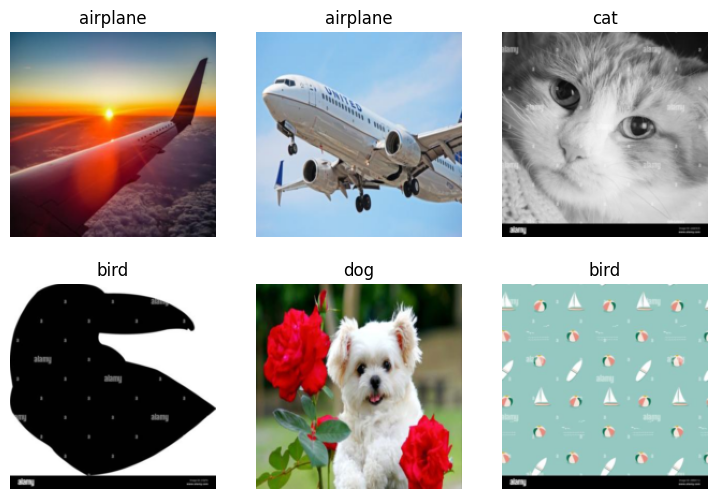

In [7]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, batch_size=64)
dls.show_batch(max_n=6)

epoch,train_loss,valid_loss,error_rate,time
0,0.641784,0.280420,0.067485,00:16


epoch,train_loss,valid_loss,error_rate,time
0,0.203239,0.256122,0.072086,00:21
1,0.126044,0.181228,0.050613,00:21


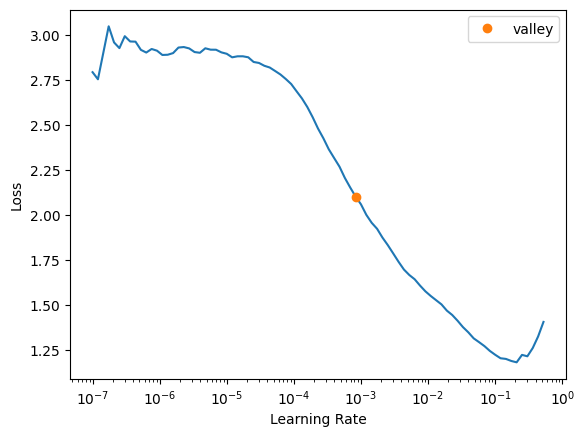

In [12]:
learn = vision_learner(dls, resnet101, metrics=error_rate)

learn.lr_find()
learn.fine_tune(2, 3e-3)

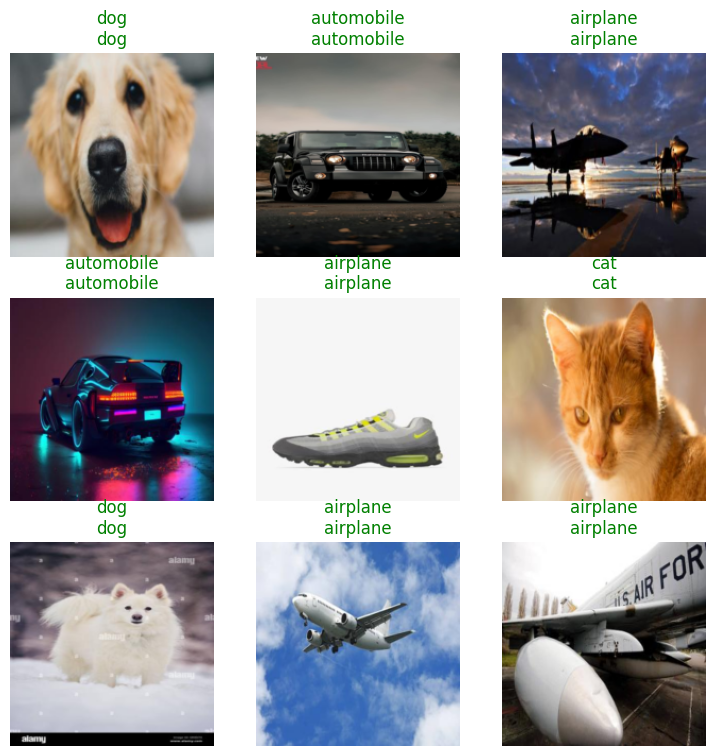

In [15]:
learn.show_results()

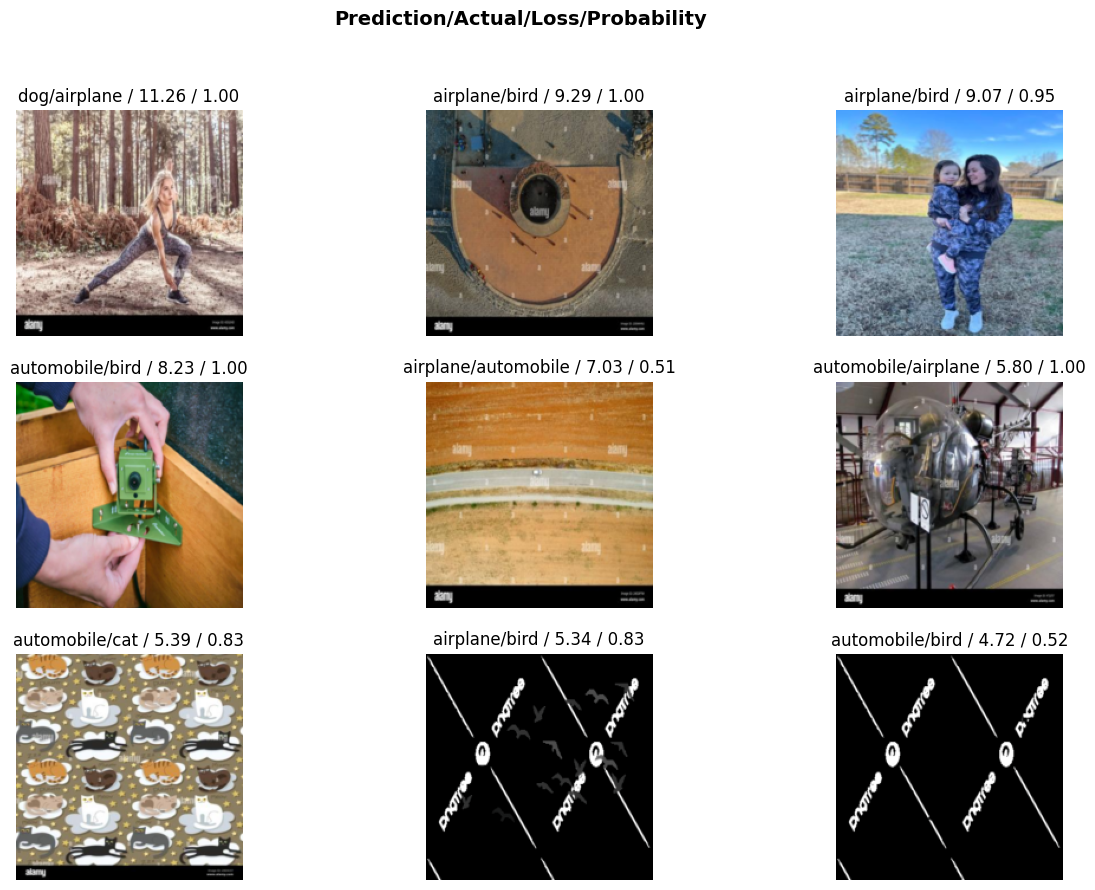

In [16]:
interp = Interpretation.from_learner(learn)
interp.plot_top_losses(9, figsize=(15,10))

## Step 3: Use our model (and build your own!)

Let's see what our model thinks about that bird we downloaded at the start:

In [19]:
pred = learn.predict(PILImage.create('bird.jpg'))
print(pred)

('bird', tensor(2), tensor([1.1616e-06, 2.0315e-07, 9.9999e-01, 8.3988e-06, 8.3587e-07]))
